In [1]:
# 1. Importera bibliotek
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 2. Läs in data
data_dir = "db_29_3_text"
occ = pd.read_csv(os.path.join(data_dir, "Occupation Data.txt"), sep='\t', encoding='utf-8')
skills = pd.read_csv(os.path.join(data_dir, "Skills.txt"), sep='\t', encoding='utf-8')
# rel = pd.read_csv(os.path.join(data_dir, "Related Occupations.txt"), sep='\t', encoding='utf-8')


In [2]:
# 3. Skapa (yrke x skill)-matriser för IM och LV
skills_lv = skills[skills['Scale ID'] == 'LV']
skills_im = skills[skills['Scale ID'] == 'IM']

# Pivotera till yrke x skill
lv_matrix = skills_lv.pivot(index='O*NET-SOC Code', columns='Element ID', values='Data Value')
im_matrix = skills_im.pivot(index='O*NET-SOC Code', columns='Element ID', values='Data Value')

# Säkerställ samma yrkesordning för båda matriser
lv_matrix = lv_matrix.reindex(im_matrix.index)


In [3]:
# 4. PCA på IM för att få (PC1, PC2)
pca = PCA(n_components=2)
im_filled = im_matrix.fillna(0)
im_coords = pca.fit_transform(im_filled.values)


In [4]:
# 5. Beräkna xi (vinkel) och chi (radie, viktad LV)
xi = np.arctan2(im_coords[:, 1], im_coords[:, 0]) % (2 * np.pi)

# Viktat LV per yrke (IM som vikt)
lv_weighted = (lv_matrix * im_matrix).sum(axis=1) / im_matrix.sum(axis=1)
chi = (lv_weighted - lv_weighted.min()) / (lv_weighted.max() - lv_weighted.min())


In [5]:
# 6. Bygg slutlig DataFrame för occupation space
occ_titles = occ.set_index('O*NET-SOC Code').reindex(im_matrix.index)['Title']

final_df = pd.DataFrame({
    'onet_code': im_matrix.index,
    'title': occ_titles.values,
    'im_pc1': im_coords[:, 0],
    'im_pc2': im_coords[:, 1],
    'xi': xi,
    'chi': chi.values,
})
final_df.head()


,onet_code,title,im_pc1,im_pc2,xi,chi
0,11-1011.00,Chief Executives,-4.311609,1.863319,2.733670,1.000000
1,11-1011.03,Chief Sustainability Officers,-3.405287,0.814943,2.906694,0.736456
2,11-1021.00,General and Operations Managers,-2.468686,0.367203,2.993931,0.693450
3,11-2011.00,Advertising and Promotions Managers,-2.895811,-0.513385,3.317055,0.701366
4,11-2021.00,Marketing Managers,-3.231712,0.008304,3.139023,0.747849


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_occupation_space_centered(
    df,
    chi_col='chi',
    xi_col='xi',
    color_col=None,
    annotate_n=12,
    figsize=(9,9),
    title=None,
    alpha=0.7,
    cmap='tab20'
):
    """
    Plotta occupation space i polära koordinater, centrerat kring tyngdpunkten.
    df: DataFrame med kolumner för vinkel (xi) och radie (chi).
    color_col: valfri kolumn att färga efter (t.ex. kluster).
    annotate_n: antal punkter med högst radie att annotera.
    """
    # 1. Omvandla till kartesiska koordinater
    x = df[chi_col] * np.cos(df[xi_col])
    y = df[chi_col] * np.sin(df[xi_col])

    # 2. Beräkna tyngdpunktens vinkel
    x_center = x.mean()
    y_center = y.mean()
    center_angle = np.pi+np.arctan2(y_center, x_center) % (2 * np.pi)

    # 3. Rotera alla xi så att tyngdpunkten hamnar vid vinkel 0
    xi_rot = (df[xi_col] - center_angle) % (2 * np.pi)

    # 4. Skapa figuren
    fig, ax = plt.subplots(figsize=figsize, subplot_kw={'projection':'polar'})

    # 5. Plotta punkterna
    if color_col and color_col in df.columns:
        categories = df[color_col].astype('category').cat.codes
        sc = ax.scatter(xi_rot, df[chi_col], c=categories, cmap=cmap, alpha=alpha, s=20)
        # Lägg till färglegend om du vill:
        handles, labels = sc.legend_elements()
        legend_labels = df[color_col].astype('category').cat.categories
        ax.legend(handles, legend_labels, title=color_col, fontsize=8, loc='best')
    else:
        ax.scatter(xi_rot, df[chi_col], color='blue', alpha=alpha, s=20)

    # 6. Annotera titlar längst ut på cirkeln
    if annotate_n > 0 and 'title' in df.columns:
        annots = df.loc[df[chi_col].nlargest(annotate_n).index]
        for _, row in annots.iterrows():
            angle = (row[xi_col] - center_angle) % (2 * np.pi)
            radius = row[chi_col]
            offset = 0.04  # justera för att lägga labeln utanför punkten
            xtext = (radius + offset) * np.cos(angle)
            ytext = (radius + offset) * np.sin(angle)
            ax.annotate(
                row['title'],
                xy=(angle, radius),
                xytext=(angle, radius + offset),
                textcoords='data',
                ha='center', va='center',
                fontsize=8,
                rotation=np.degrees(angle)-0,
                rotation_mode='anchor'
            )

    # 7. Polär plot styling
    ax.set_rlabel_position(0)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_theta_zero_location('E')  # Nollpunkt (0) till höger
    ax.set_theta_direction(1)        # Vinklar ökar moturs
    if title:
        ax.set_title(title, fontsize=14)
    plt.tight_layout()
    plt.show()
    return fig, ax


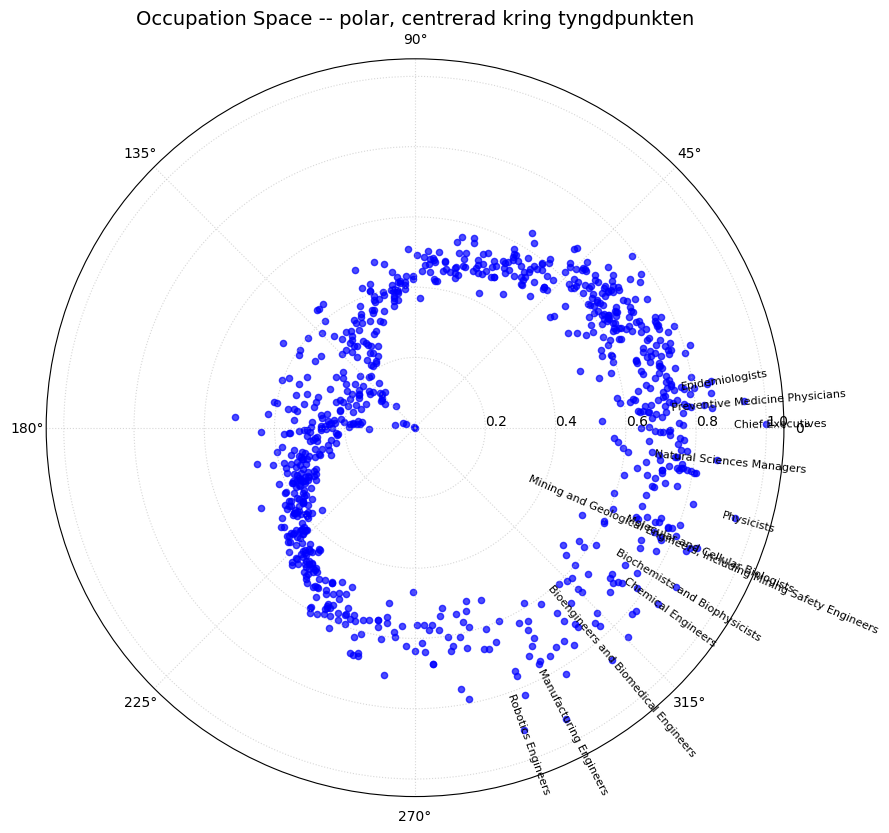

(<Figure size 900x900 with 1 Axes>,
 <PolarAxes: title={'center': 'Occupation Space -- polar, centrerad kring tyngdpunkten'}>)

In [18]:
# 8. Visualisera occupation space!
plot_occupation_space_centered(
    final_df,
    chi_col='chi',
    xi_col='xi',
    color_col=None,     # eller t.ex. 'cluster' om sådan finns
    annotate_n=12,
    title='Occupation Space -- polar, centrerad kring tyngdpunkten'
)
